# Gruppo 2613
- Giacomo Bregolin 2188429
- Leonardo Fardin
- Lara Fogarolo 2199475
- Francesco Peron 2185610

# Point 1

In [1]:
import numpy as np
import pandas as pd
import random
from keras.models import Sequential
from keras.layers import Dense, Dropout
import keras_tuner
import keras

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py

# training/validation/test fractions
perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15
#  check it sums to 1 
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

2026-03-11 21:17:16.512874: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Keras works with numpy arrays: just use them from the start

TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 8400
valid: 1800
test: 1800


In [3]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check 
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 8400 	 Validation: 1800 	 Test: 1800
after rescaling (train):
mean value= [ 9.17572896e-16  1.18834043e-14 -1.95478554e-15 -3.53337069e-15
 -6.42594443e-15 -2.40365928e-15 -2.88332932e-15 -8.27623684e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


The neural network can choose between:
- Dropout rate: 0.0, 0.1, 0.2, 0.3
- Activation function of inner layers: RELU, ELU
- Learning rate: 1e-6 up to 1e-2
- Optimizer: Adam, SGD, RMSProp, Nesterov(NAdam)

We then run a search to find the best combination for our data.

We did search also the optimal best batch size to see how it affected the model but since the results didin't show a difference in the batch size (maybe we needed to choose more larger or smaller sizes) it was not considered for finding the best model at the end.

In [4]:
from keras import Input

def build_model(hp):
    model = Sequential()
    
    # Input layer (new style)
    model.add(Input(shape=(L,)))
    model.add(Dense(L, activation='relu'))
    
    # Search over dropout rate
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.4, step=0.1)
    activation = hp.Choice("activation", values=["relu", "elu"])
    
    # Inner layers
    model.add(Dense(20, activation=activation))
    model.add(Dropout(dropout_rate))
    model.add(Dense(20, activation=activation))
    model.add(Dropout(dropout_rate))
    model.add(Dense(20, activation=activation))
    model.add(Dropout(dropout_rate))
    
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Search over learning rate
    learning_rate = hp.Float("learning_rate", min_value=1e-6, max_value=1e-1, sampling="log")
    
    # Search over optimizer
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop", "nadam"])
    
    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "nadam":
        optimizer = keras.optimizers.Nadam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [8]:
# USARE QUESTO SOLO PER CREARE NUOVI DATI
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=50,
    executions_per_trial=2,
    overwrite=True,
    directory="new_trials",
    project_name="my_search"
)

tuner.search(x_train, y_train,
             epochs=100,
             validation_data=(x_valid, y_valid),
             verbose=2)

Trial 50 Complete [00h 01m 59s]
val_accuracy: 0.5455555617809296

Best val_accuracy So Far: 0.9849999845027924
Total elapsed time: 01h 40m 25s


In [10]:
# USARE QUESTO SOLO PER CREARE NUOVI DATI
# CHeck what happens when we change the batch size
batch_sizes = np.arange(35,55,1)
batch_results = []

for bs in batch_sizes:
    tuner2 = keras_tuner.RandomSearch(
        hypermodel=build_model,
        objective="val_accuracy",
        max_trials=5,
        overwrite=False,
        directory="my_dir",
        project_name=f"batch_{bs}"
    )
    tuner2.search(x_train, y_train,
                 epochs=75,
                 batch_size=bs,
                 validation_data=(x_valid, y_valid),
                 verbose=2)
    
    best_hp = tuner2.get_best_hyperparameters(1)[0]
    best_acc = tuner2.oracle.get_best_trials(1)[0].score
    batch_results.append({"batch_size": bs, "val_accuracy": best_acc})


batch = pd.DataFrame(batch_results)
print(batch)

Trial 5 Complete [00h 01m 51s]
val_accuracy: 0.8527777791023254

Best val_accuracy So Far: 0.9777777791023254
Total elapsed time: 00h 11m 20s
Reloading Tuner from my_dir/batch_37/tuner0.json
Reloading Tuner from my_dir/batch_38/tuner0.json
Reloading Tuner from my_dir/batch_39/tuner0.json
Reloading Tuner from my_dir/batch_40/tuner0.json
Reloading Tuner from my_dir/batch_41/tuner0.json
Reloading Tuner from my_dir/batch_42/tuner0.json
Reloading Tuner from my_dir/batch_43/tuner0.json
Reloading Tuner from my_dir/batch_44/tuner0.json
Reloading Tuner from my_dir/batch_45/tuner0.json
Reloading Tuner from my_dir/batch_46/tuner0.json
Reloading Tuner from my_dir/batch_47/tuner0.json
Reloading Tuner from my_dir/batch_48/tuner0.json
Reloading Tuner from my_dir/batch_49/tuner0.json
Reloading Tuner from my_dir/batch_50/tuner0.json
Reloading Tuner from my_dir/batch_51/tuner0.json
Reloading Tuner from my_dir/batch_52/tuner0.json
Reloading Tuner from my_dir/batch_53/tuner0.json
Reloading Tuner from my_d

In [5]:
# PER RECUPERARE I DATI DEL TRAINING
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=50,
    executions_per_trial=2,
    overwrite=False,
    directory="trials",
    project_name="my_search"
)
trials = tuner.oracle.trials

# Extract dropout rate and val_accuracy for each trial
results = []
for trial in trials.values():
    dropout = trial.hyperparameters.values["dropout_rate"]
    lr = trial.hyperparameters.values["learning_rate"]
    optimizer = trial.hyperparameters.values["optimizer"]
    val_acc = trial.score  # best val_accuracy for that trial
    results.append({"dropout_rate": dropout, "learning_rate": lr,
                    "optimizer": optimizer, "val_accuracy": val_acc})

# Convert to DataFrame
df = pd.DataFrame(results)
print(df)

# different batch size
batch_sizes = np.arange(35,55,1)
batch_results = []

for bs in batch_sizes:
    tuner2 = keras_tuner.RandomSearch(
        hypermodel=build_model,
        objective="val_accuracy",
        max_trials=5,
        overwrite=False,
        directory="my_dir",
        project_name=f"batch_{bs}"
    )
    best_hp = tuner2.get_best_hyperparameters(1)[0]
    best_acc = tuner2.oracle.get_best_trials(1)[0].score
    batch_results.append({"batch_size": bs, "val_accuracy": best_acc})


batch = pd.DataFrame(batch_results)
print(batch)

Reloading Tuner from trials/my_search/tuner0.json
    dropout_rate  learning_rate optimizer  val_accuracy
0            0.1       0.000009       sgd      0.503333
1            0.1       0.000017   rmsprop      0.548611
2            0.0       0.000029     nadam      0.542778
3            0.1       0.025796     nadam      0.968333
4            0.2       0.000294       sgd      0.545556
5            0.4       0.000010   rmsprop      0.539444
6            0.3       0.000005     nadam      0.555000
7            0.4       0.000172     nadam      0.692778
8            0.3       0.051722     nadam      0.582222
9            0.4       0.010627       sgd      0.910833
10           0.1       0.022805       sgd      0.951389
11           0.2       0.000012   rmsprop      0.545556
12           0.3       0.000002   rmsprop      0.541944
13           0.1       0.000009     nadam      0.539167
14           0.0       0.000010       sgd      0.503611
15           0.3       0.016211   rmsprop      0.83138

I0000 00:00:1773260254.231266    6892 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2253 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [6]:
# Get the top 2 models.
models = tuner.get_best_models(num_models=2)
best_model = models[0]
best_model.summary()

/home/fra/anaconda3/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/fra/anaconda3/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 23 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113 (4.35 KB)

 Trainable params: 1,113 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#takes as parameters a list of models, the datasaet
#and the number of k-folds
#gives back the best model index in the list and
#the list of errors for the models
def cross_validation(models, x, y, k=5)->tuple:
    import numpy as np

    #gives back the cost for the given model
    def fit(model, x_train, y_train, x_val, y_val):
        model.fit(x, y)
        y_pred = model.predict(x_val)
        # Return a single float to minimize.
        return np.mean((y_pred - y_val)**2)

    #shuffling the indexes for shuflling the dataset
    #before dividing it in k folds
    idxs = np.arange(y.size)
    np.random.shuffle(idxs)

    #creating folds
    x_fold = []
    y_fold = []

    for i in range(k):
        x_fold.append(x[idxs[i::k]])
        y_fold.append(y[idxs[i::k]])

    #testing the models
    errors = []
    for model in models:
        error = 0
        for i in range(k):
            error += fit(model, x_fold[not i], y_fold[not i],
                                x_fold[i], y_fold[i])
        error.append(error)

    #finding the index of the lowest-cost-model
    errors = np.array(errors)
    best_idx = np.argmin(errors)

    return best_idx, errors

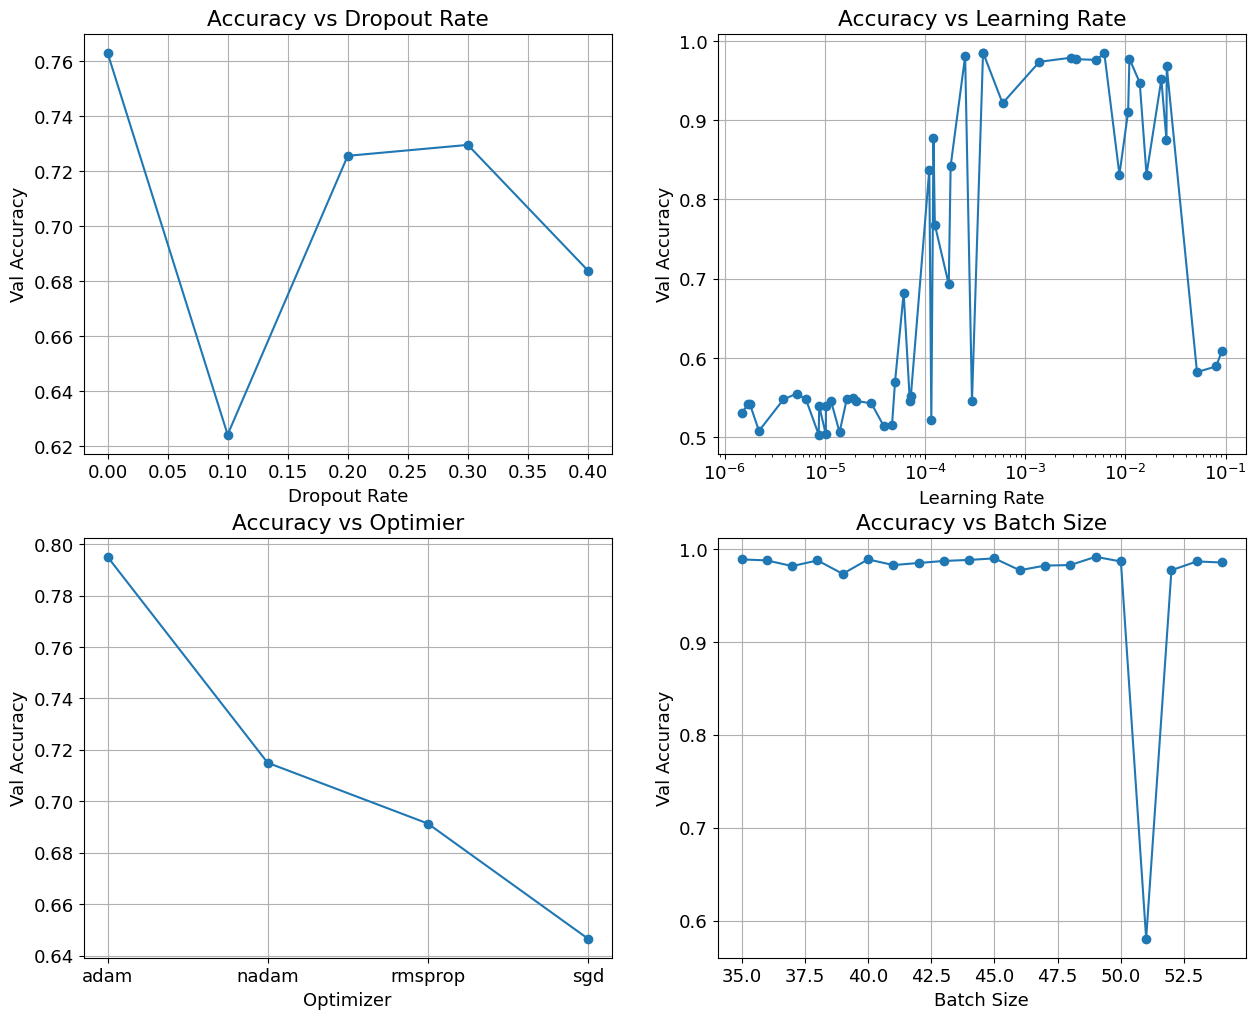

In [23]:
import matplotlib.pyplot as plt

'''
Here we show the results of the search for the best model.
'''

fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(15,12))
# Group by dropout and average val_accuracy
drop = df.groupby("dropout_rate")["val_accuracy"].mean()
lear = df.groupby("learning_rate")["val_accuracy"].mean()
opti = df.groupby("optimizer")["val_accuracy"].mean()


ax[0][0].plot(drop.index, drop.values, marker='o')
ax[0][0].set_xlabel("Dropout Rate")
ax[0][0].set_ylabel("Val Accuracy")
ax[0][0].set_title("Accuracy vs Dropout Rate")
ax[0][0].grid(True)

ax[0][1].plot(lear.index, lear.values, marker='o')
ax[0][1].set_xscale("log")
ax[0][1].set_xlabel("Learning Rate")
ax[0][1].set_ylabel("Val Accuracy")
ax[0][1].set_title("Accuracy vs Learning Rate")
ax[0][1].grid(True)

ax[1][0].plot(opti.index, opti.values, marker='o')
ax[1][0].set_xlabel("Optimizer")
ax[1][0].set_ylabel("Val Accuracy")
ax[1][0].set_title("Accuracy vs Optimier")
ax[1][0].grid(True)

ax[1][1].plot(batch['batch_size'],batch['val_accuracy'], marker='o')
ax[1][1].set_xlabel("Batch Size")
ax[1][1].set_ylabel("Val Accuracy")
ax[1][1].set_title("Accuracy vs Batch Size")
ax[1][1].grid(True)
plt.show()

Above are the results we found. Each point is given by the of all model with that specific value(dropout, learning rate, ecc.)

Epoch 1/200


2026-03-11 21:20:42.212549: I external/local_xla/xla/service/service.cc:163] XLA service 0x77b6f00076e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-11 21:20:42.212573: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 SUPER, Compute Capability 7.5
2026-03-11 21:20:42.290650: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-11 21:20:42.565654: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
I0000 00:00:1773260443.496984    7098 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


168/168 - 3s - 16ms/step - accuracy: 0.9863 - loss: 0.0391 - val_accuracy: 0.9806 - val_loss: 0.0457
Epoch 2/200
168/168 - 0s - 2ms/step - accuracy: 0.9879 - loss: 0.0379 - val_accuracy: 0.9844 - val_loss: 0.0457
Epoch 3/200
168/168 - 0s - 2ms/step - accuracy: 0.9893 - loss: 0.0369 - val_accuracy: 0.9844 - val_loss: 0.0474
Epoch 4/200
168/168 - 0s - 2ms/step - accuracy: 0.9906 - loss: 0.0355 - val_accuracy: 0.9833 - val_loss: 0.0453
Epoch 5/200
168/168 - 0s - 2ms/step - accuracy: 0.9887 - loss: 0.0368 - val_accuracy: 0.9850 - val_loss: 0.0425
Epoch 6/200
168/168 - 0s - 2ms/step - accuracy: 0.9899 - loss: 0.0364 - val_accuracy: 0.9811 - val_loss: 0.0473
Epoch 7/200
168/168 - 0s - 2ms/step - accuracy: 0.9895 - loss: 0.0357 - val_accuracy: 0.9822 - val_loss: 0.0448
Epoch 8/200
168/168 - 0s - 2ms/step - accuracy: 0.9893 - loss: 0.0363 - val_accuracy: 0.9844 - val_loss: 0.0450
Epoch 9/200
168/168 - 0s - 2ms/step - accuracy: 0.9888 - loss: 0.0359 - val_accuracy: 0.9839 - val_loss: 0.0455
Epo

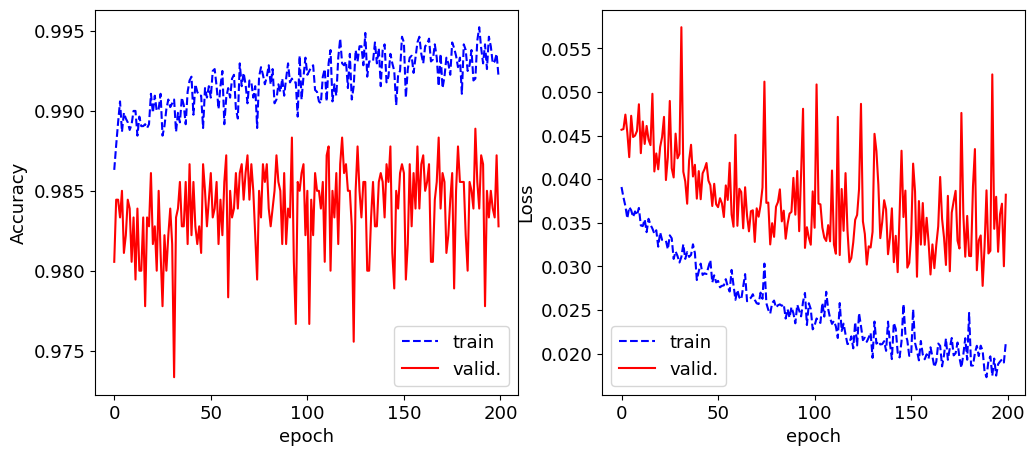

In [17]:
'''
We train the best model over training data
'''


fit = best_model.fit(x_train, y_train,
               epochs = 200, batch_size = 50,
               validation_data=(x_valid,y_valid),
               verbose=2)
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

In [20]:
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.0781
Final test accuracy: 0.9689


319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


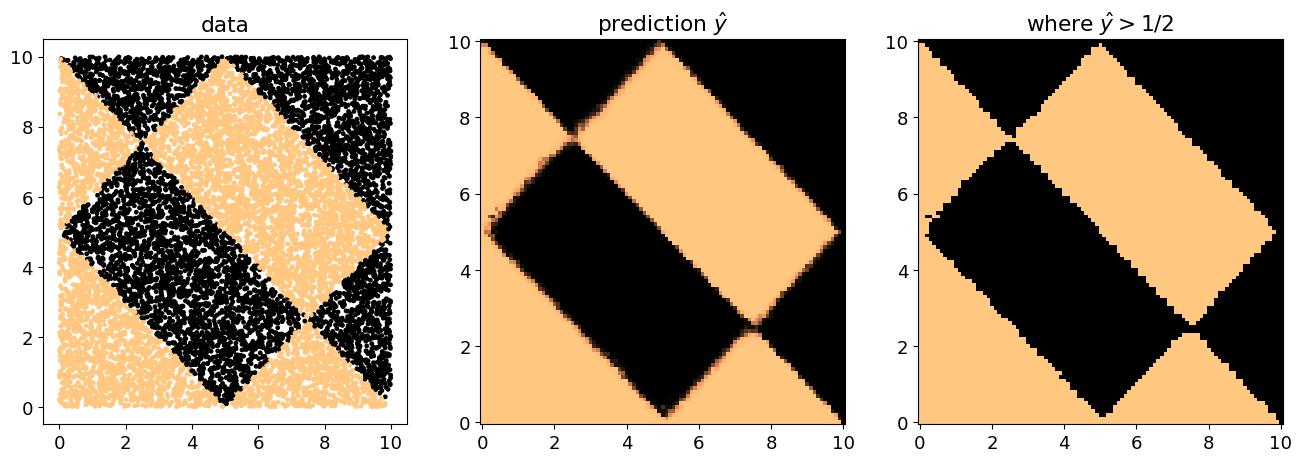

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [22]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = best_model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")

# Point 2

In [36]:
'''
putting in rid the dataset reduced
keeping 50%, 75%, 90%
'''
rid_x = []
rid_y = []
perc_list = [0.5, 0.75, 0.9]
for perc_keep in perc_list:
    indices = random.sample(range(0,len(x)), int(len(x)*perc_keep))
    x_rid = x[indices]
    y_rid = y[indices]
    rid_x.append(x_rid)
    rid_y.append(y_rid)

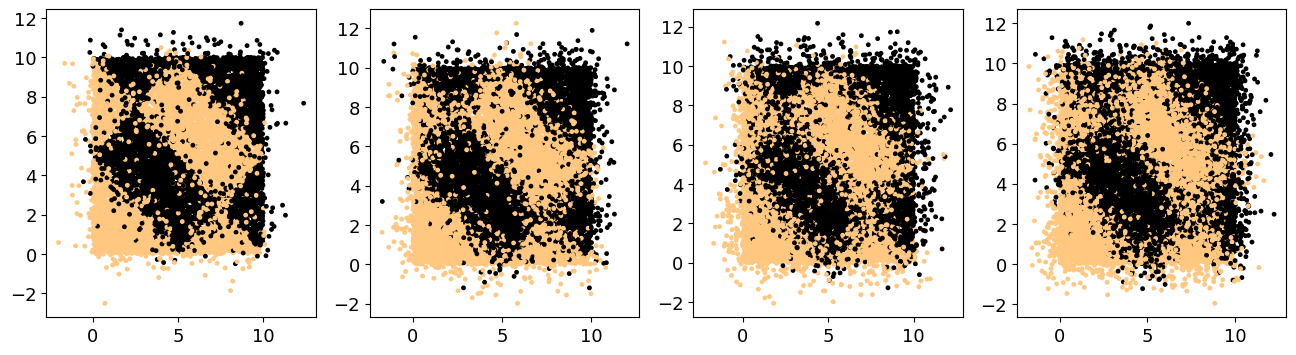

In [17]:
'''
generating training datsets with random gaussian noise
'''
fig, ax = plt.subplots(nrows=1, ncols=4,figsize=(16,4))
perc_aug = [0.2,0.4,0.6,0.8]
aug_xg = []
aug_yg = []
for i,p in enumerate(perc_aug):
    g_noise = np.random.normal(0, 0.8, (int(len(x_train)*p),8))
    indicies = random.sample(range(0,len(x_train)), len(g_noise))
    x_train_new = x_train[indicies] + g_noise
    x_train_g_noise = np.concatenate((x_train, x_train_new))
    y_train_new = y_train[indicies]
    y_train_g_noise = np.concatenate((y_train, y_train_new))
    aug_xg.append(x_train_g_noise)
    aug_yg.append(y_train_g_noise)
    ax[i].scatter(x_train_g_noise[:,0],x_train_g_noise[:,1],s=6,c=y_train_g_noise)

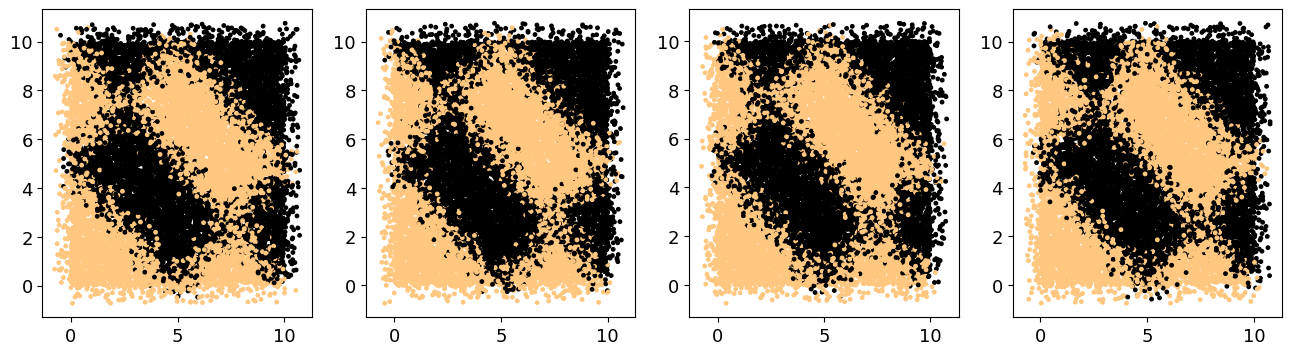

In [18]:
'''
generating training datsets with random exponential noise
'''
fig, ax = plt.subplots(nrows=1, ncols=4,figsize=(16,4))
perc_aug = [0.2,0.4,0.6,0.8]
aug_xe = []
aug_ye = []
for i,p in enumerate(perc_aug):
    e_noise = np.tanh(np.sin(g_noise)) 
    indicies = random.sample(range(0,len(x_train)), len(e_noise))
    x_train_new = x_train[indicies] + e_noise
    x_train_e_noise = np.concatenate((x_train, x_train_new))
    y_train_new = y_train[indicies]
    y_train_e_noise = np.concatenate((y_train, y_train_new))
    aug_xe.append(x_train_e_noise)
    aug_ye.append(y_train_e_noise)
    ax[i].scatter(x_train_e_noise[:,0],x_train_e_noise[:,1],s=6,c=y_train_e_noise)

In [86]:
'''
saving hyperparameters of the best model
'''

acc = df['val_accuracy'].max()
best_row = df.loc[df['val_accuracy'].idxmax()]
dropout = best_row['dropout_rate']
lr = best_row['learning_rate']
optimizer = best_row['optimizer']
print("Row with best val_accuracy:")
print(best_row)

Row with best val_accuracy:
dropout_rate          0.0
learning_rate    0.000379
optimizer            adam
val_accuracy        0.985
Name: 13, dtype: object


In [87]:
'''
Training the best model on each reducted training set and saving the results
'''

from tensorflow.keras.models import clone_model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

Fit_r = []
model_r = []

for x_train_r, y_train_r in zip(rid_x, rid_y):

    tf.keras.backend.clear_session()
    model = clone_model(best_model)
    optimizer = Adam(learning_rate=lr) 

    model.compile(
        optimizer=optimizer,
        loss=best_model.loss,
        metrics=['accuracy']  
    )


    fit = model.fit(
        x_train_r, y_train_r,
        validation_data=(x_valid, y_valid),
        epochs=75,
        verbose=0
    )

    Fit_r.append(fit)
    model_r.append(model)

0.9711111187934875


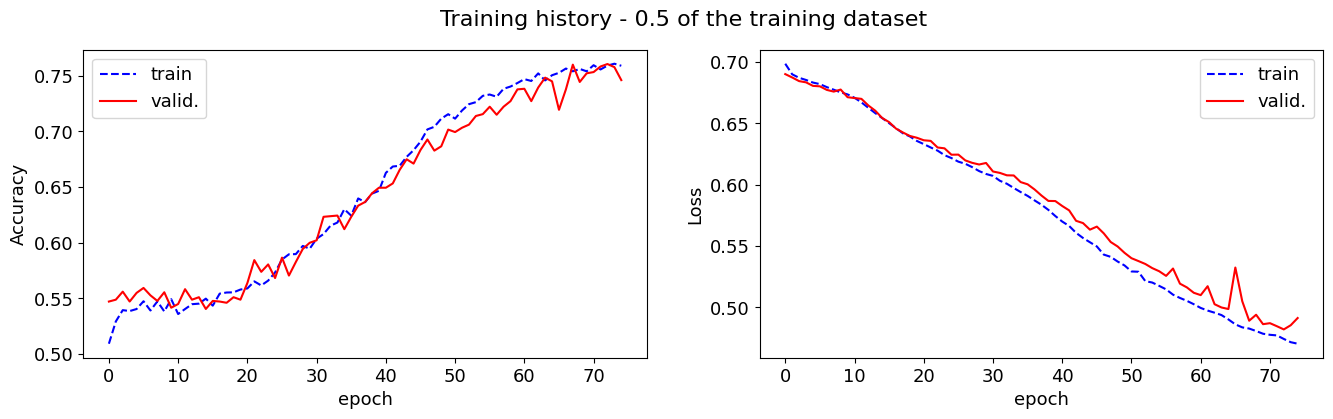

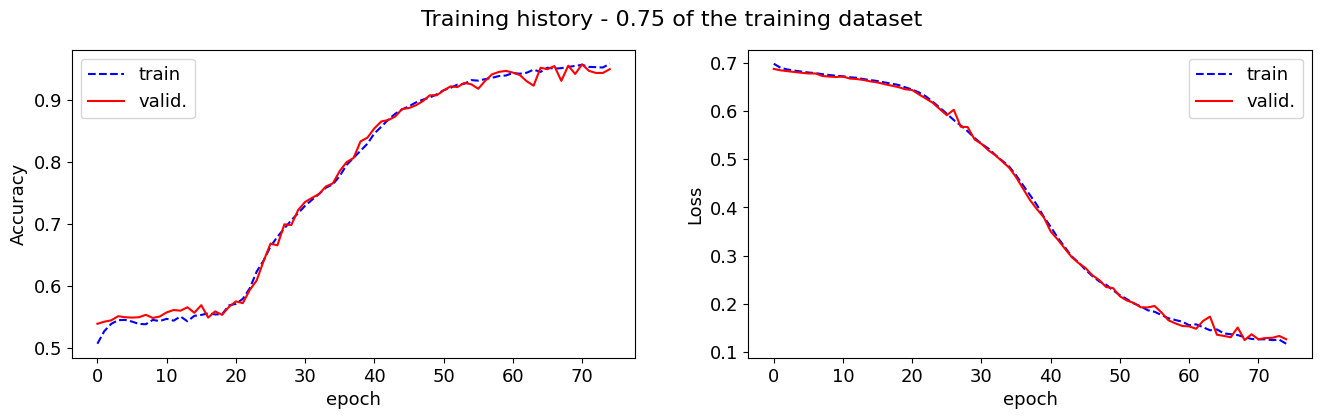

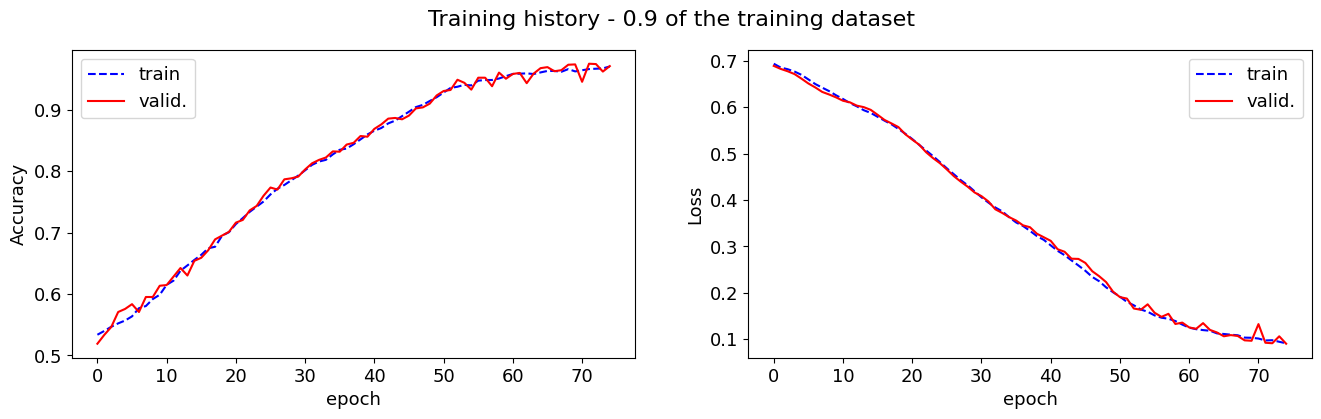

In [88]:
'''
Validation for reduced training sets
'''
best_a = 0
for i,fit in enumerate(Fit_r):
    fig,AX=plt.subplots(1,2,figsize=(16,4.))
    ax=AX[0]
    fig.suptitle(f'Training history - {perc_list[i]} of the training dataset', fontsize=16)
    ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_loss'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.legend()
    if fit.history['val_accuracy'][-1] > best_a:
        best_a = fit.history['val_accuracy'][-1]
        best_model_r = model_r[i]
print(best_a)


In [90]:
'''
training the best model on the augmented gaussian training sets and saving the results
'''
Fit_ag = []
model_ag = []

for x_train_ag, y_train_ag in zip(aug_xg, aug_yg):

    tf.keras.backend.clear_session()
    model = clone_model(best_model)
    optimizer = Adam(learning_rate=lr) 

    model.compile(
        optimizer=optimizer,
        loss=best_model.loss,
        metrics=['accuracy']  
    )


    fit = model.fit(
        x_train_ag, y_train_ag,
        validation_data=(x_valid, y_valid),
        epochs=75,
        verbose=0
    )
    
    Fit_ag.append(fit)
    model_ag.append(model)

0.9472222328186035


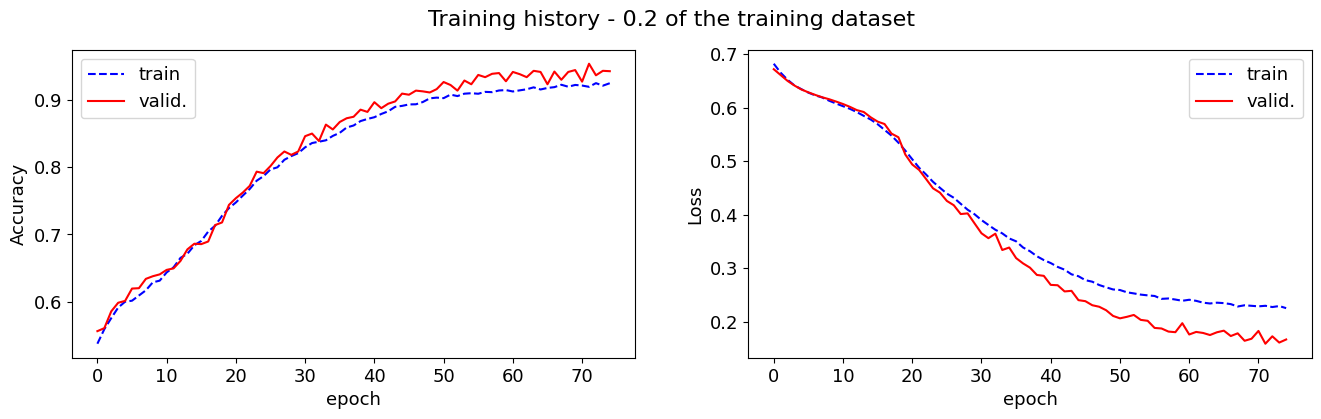

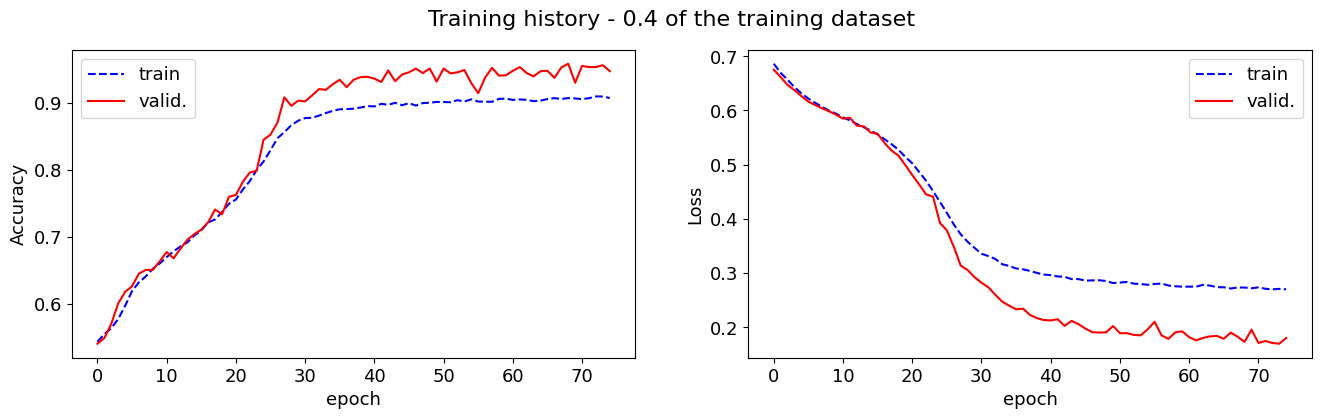

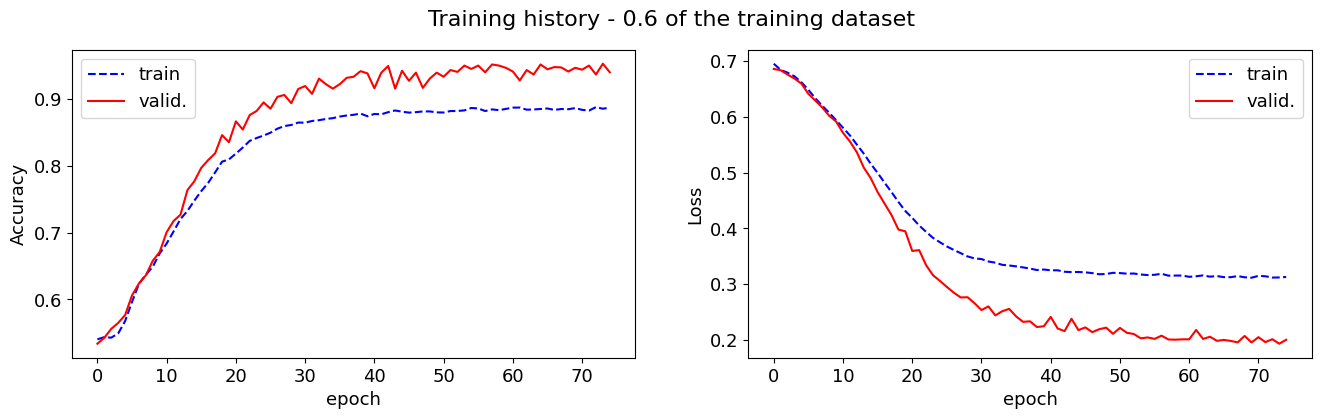

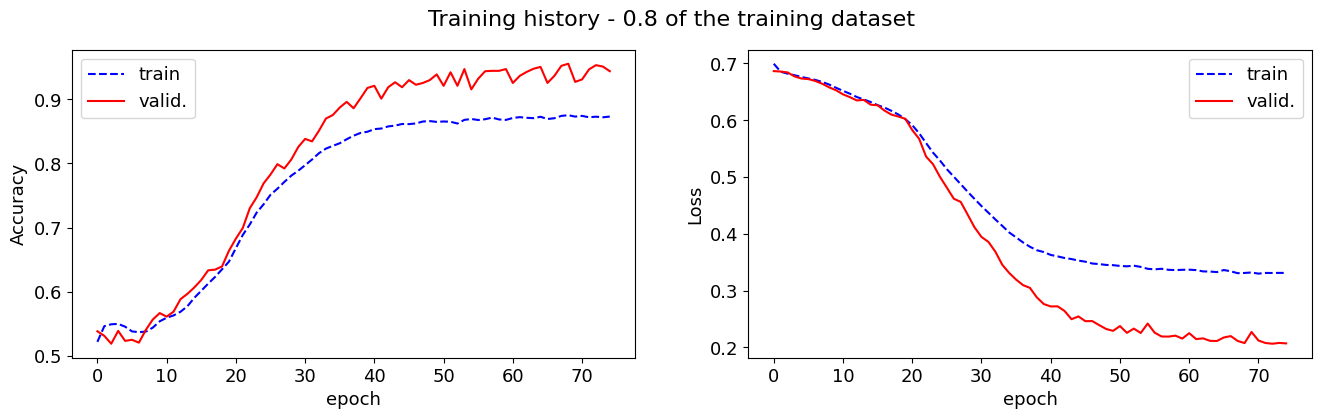

In [92]:
'''
validation for augmented gaussian training sets
'''
best_aag = 0
for i,fit in enumerate(Fit_ag):
    fig,AX=plt.subplots(1,2,figsize=(16,4.))
    ax=AX[0]
    fig.suptitle(f'Training history - {perc_aug[i]} of the training dataset', fontsize=16)
    ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_loss'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.legend()
    if fit.history['val_accuracy'][-1] > best_aag:
        best_aag = fit.history['val_accuracy'][-1]
        best_model_ag = model_ag[i]
print(best_aag)

In [93]:
'''
training of the best model on the augmented non gaussian training sets and saving the results
'''
Fit_ae = []
model_ae = []

for x_train_ae, y_train_ae in zip(aug_xe, aug_ye):

    tf.keras.backend.clear_session()
    model = clone_model(best_model)
    optimizer = Adam(learning_rate=lr) 

    model.compile(
        optimizer=optimizer,
        loss=best_model.loss,
        metrics=['accuracy']  
    )


    fit = model.fit(
        x_train_ae, y_train_ae,
        validation_data=(x_valid, y_valid),
        epochs=75,
        verbose=0
    )
    Fit_ae.append(fit)
    model_ae.append(model)

0.9572222232818604


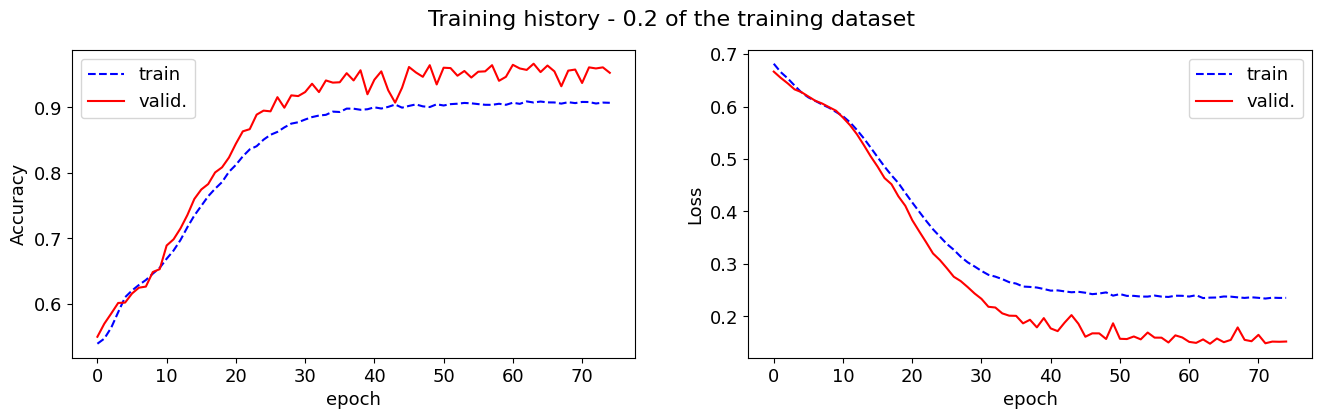

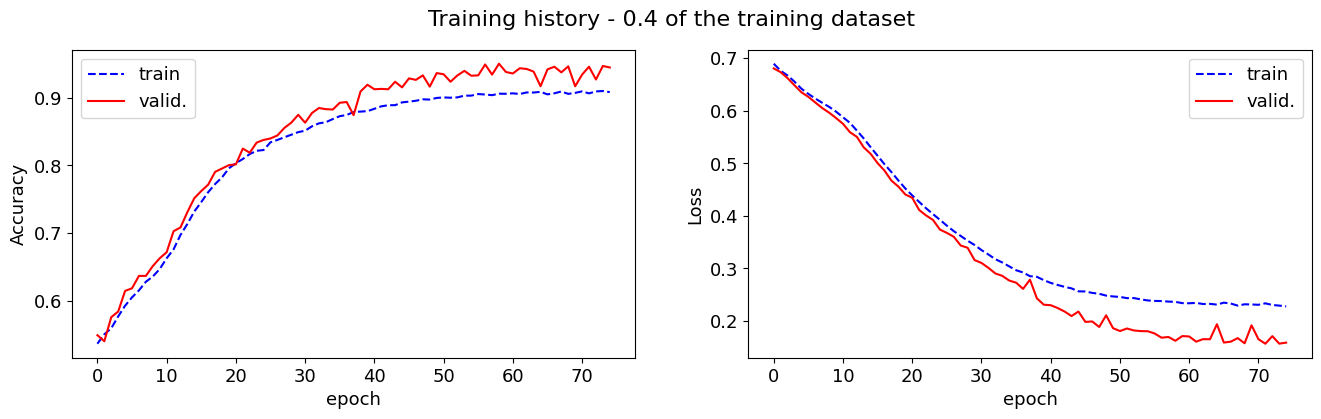

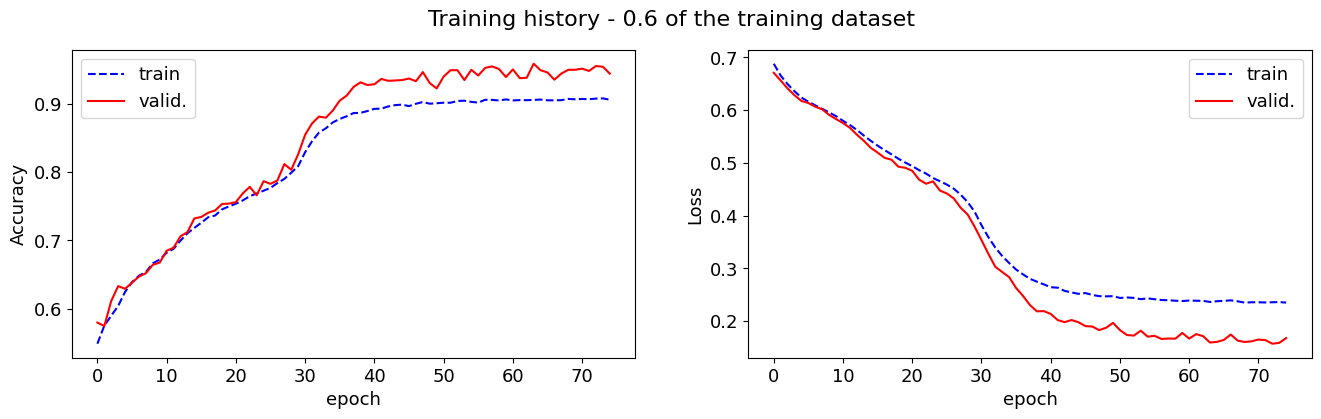

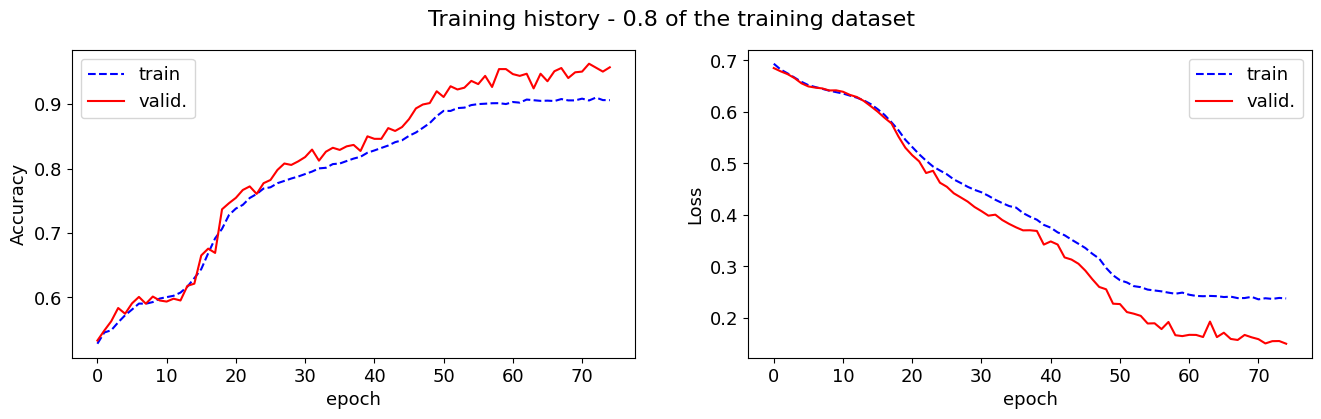

In [94]:
'''
validation for augmented non gaussian training sets
'''
best_aae = 0
for i,fit in enumerate(Fit_ae):
    fig,AX=plt.subplots(1,2,figsize=(16,4.))
    ax=AX[0]
    fig.suptitle(f'Training history - {perc_aug[i]} of the training dataset', fontsize=16)
    ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_loss'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.legend()
    if fit.history['val_accuracy'][-1] > best_aae:
        best_aae = fit.history['val_accuracy'][-1]
        best_model_ae = model_ae[i]
print(best_aae)

In [95]:
'''
The validation is executed on every modified set (reduced and augmented)
The comparison of the models is done on the results of the validation 
The test is done only on the best model from validation
'''

'\nThe validation is executed on every modified set (reduced and augmented)\nThe comparison of the models is done on the results of the validation \nThe test is done only on the best model from validation\n'

In [97]:
'''
Finding the max value of the accuracy
'''

max_value = max(best_a, best_aag, best_aae)

if max_value == best_a:
    best_var = "best_a"
elif max_value == best_aag:
    best_var = "best_aag"
else:
    best_var = "best_aae"

print(f"{best_var}")

best_a


In [98]:
'''
Testing the best model on the test set
'''

test_loss, test_acc = best_model_r.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.0903
Final test accuracy: 0.9739
